# Exploring Shot Events in La Liga 2017/18: A Statistical Analysis of Shooting Patterns and Outcomes

In [4]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

## Data loading and preprocessing

In [5]:
# Load the data
with open("final_df.json", "r") as f:
    data = json.load(f)

df_raw = pd.DataFrame(data)

# Select variables
cols = {
    "shot.statsbomb_xg":   "xg",
    "shot.outcome.name":   "outcome",
    "shot.body_part.name": "body_part",
    "play_pattern.name":   "play_pattern",
    "under_pressure":      "under_pressure",
    "shot.first_time":     "first_time",
    "location":            "location",
}

df = df_raw[list(cols.keys())].rename(columns=cols).copy()

print("Shape after selection:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:\n", df.head(3))

Shape after selection: (971, 7)

Columns: ['xg', 'outcome', 'body_part', 'play_pattern', 'under_pressure', 'first_time', 'location']

Sample:
          xg  outcome   body_part    play_pattern under_pressure first_time  \
0  0.008752    Saved  Right Foot   From Throw In           None       None   
1  0.053915  Blocked  Right Foot  From Free Kick           None       None   
2  0.080842    Saved   Left Foot   From Throw In           None       True   

        location  
0  [101.0, 21.3]  
1  [103.9, 28.4]  
2  [112.5, 26.0]  


In [6]:
# Drop the "Other" body part category due to its ambiguity and low frequency
df = df[df["body_part"] != "Other"].reset_index(drop=True)

# Derive the goal indicator column from the outcome column
df["goal"] = (df["outcome"] == "Goal").astype(int)

# Derive the distance from the goal
# The location coordinates are in the format (x, y), where (0, 0) is the bottom left corner of the pitch and (120, 80) is the top right corner.
GOAL_X, GOAL_Y = 120.0, 40.0
df["loc_x"] = df["location"].apply(lambda v: v[0])
df["loc_y"] = df["location"].apply(lambda v: v[1])
df["distance"] = np.sqrt((df["loc_x"] - GOAL_X)**2 + (df["loc_y"] - GOAL_Y)**2)

# Derive the angle between the shot and the goal
POST1_Y, POST2_Y = 36.0, 44.0

def shot_angle(x, y):
    """
    Calculate the angle between the shot and the goal.
    :param x: shot x coordinate
    :param y: shot y coordinate
    :return: calculate angle in degrees
    """
    dx  = GOAL_X - x
    dy1 = POST1_Y - y
    dy2 = POST2_Y - y
    a1  = np.arctan2(dy1, dx)
    a2  = np.arctan2(dy2, dx)
    angle = np.abs(a2 - a1)
    angle = np.where(angle > np.pi, 2*np.pi - angle, angle)
    return np.degrees(angle)

# Calculate the angle between the shot and the goal
df["angle"] = shot_angle(df["loc_x"].values, df["loc_y"].values)

# Fill binary NaN values with False
for col in ["under_pressure", "first_time"]:
    df[col] = df[col].fillna(False).astype(bool)

# Group the small categories of play patterns into the "Other" category (less than 10 chances)
minor = ["From Kick Off", "Other", "From Keeper"]
df["play_pattern"] = df["play_pattern"].apply(lambda x: "Other" if x in minor else x)

# Final selection
df = df[["xg", "distance", "angle", "goal","body_part", "play_pattern","under_pressure", "first_time"]].copy()

In [7]:
# Validation
print("Final shape:", df.shape)
print("\nSample:\n", df.head(3))

Final shape: (968, 8)

Sample:
          xg   distance      angle  goal   body_part    play_pattern  \
0  0.008752  26.658770  12.341965     0  Right Foot   From Throw In   
1  0.053915  19.843639  18.826717     0  Right Foot  From Free Kick   
2  0.080842  15.882380  14.250033     0   Left Foot   From Throw In   

   under_pressure  first_time  
0           False       False  
1           False       False  
2           False        True  


## Descriptive analytics

### Summary statistics for quantitative variables

In [8]:
summary = df[["xg", "distance", "angle"]].describe().T
summary.columns = ["Count", "Mean", "Std", "Min", "Q1", "Median", "Q3", "Max"]
summary = summary[["Mean", "Std", "Min", "Q1", "Median", "Q3", "Max"]]
summary = summary.round(4)
print(summary)

             Mean      Std     Min       Q1   Median       Q3       Max
xg         0.1122   0.1483  0.0032   0.0339   0.0620   0.1162    0.8915
distance  18.5415   8.1612  2.2804  12.1649  17.6739  24.2466   65.8825
angle     25.2749  14.4881  1.8361  15.5944  20.3796  30.6973  121.5348


### Goal Rate overall and by group

#### Overall goal rate

In [9]:
print(f"Goals: {df['goal'].sum()} / {len(df)} = {df['goal'].mean():.4f}")

Goals: 112 / 968 = 0.1157


#### Goal rate by body part

In [10]:
print(df.groupby("body_part")["goal"].agg(["sum", "count", "mean"]).round(4))

            sum  count    mean
body_part                     
Head          9    122  0.0738
Left Foot    51    407  0.1253
Right Foot   52    439  0.1185


#### Goal rate by play pattern

In [11]:
print(df.groupby("play_pattern")["goal"].agg(["sum", "count", "mean"]).round(4))

                sum  count    mean
play_pattern                      
From Corner      11    156  0.0705
From Counter      6     53  0.1132
From Free Kick   15    190  0.0789
From Goal Kick    4     32  0.1250
From Throw In    18    136  0.1324
Other             8     25  0.3200
Regular Play     50    376  0.1330


#### Goal rate by pressure

In [12]:
print(df.groupby("under_pressure")["goal"].agg(["sum", "count", "mean"]).round(4))

                sum  count    mean
under_pressure                    
False            93    820  0.1134
True             19    148  0.1284


#### Goal rate by first time shot

In [13]:
print(df.groupby("first_time")["goal"].agg(["sum", "count", "mean"]).round(4))

            sum  count    mean
first_time                    
False        56    645  0.0868
True         56    323  0.1734


## Visualizations

### Distribution of xG, distance, angle

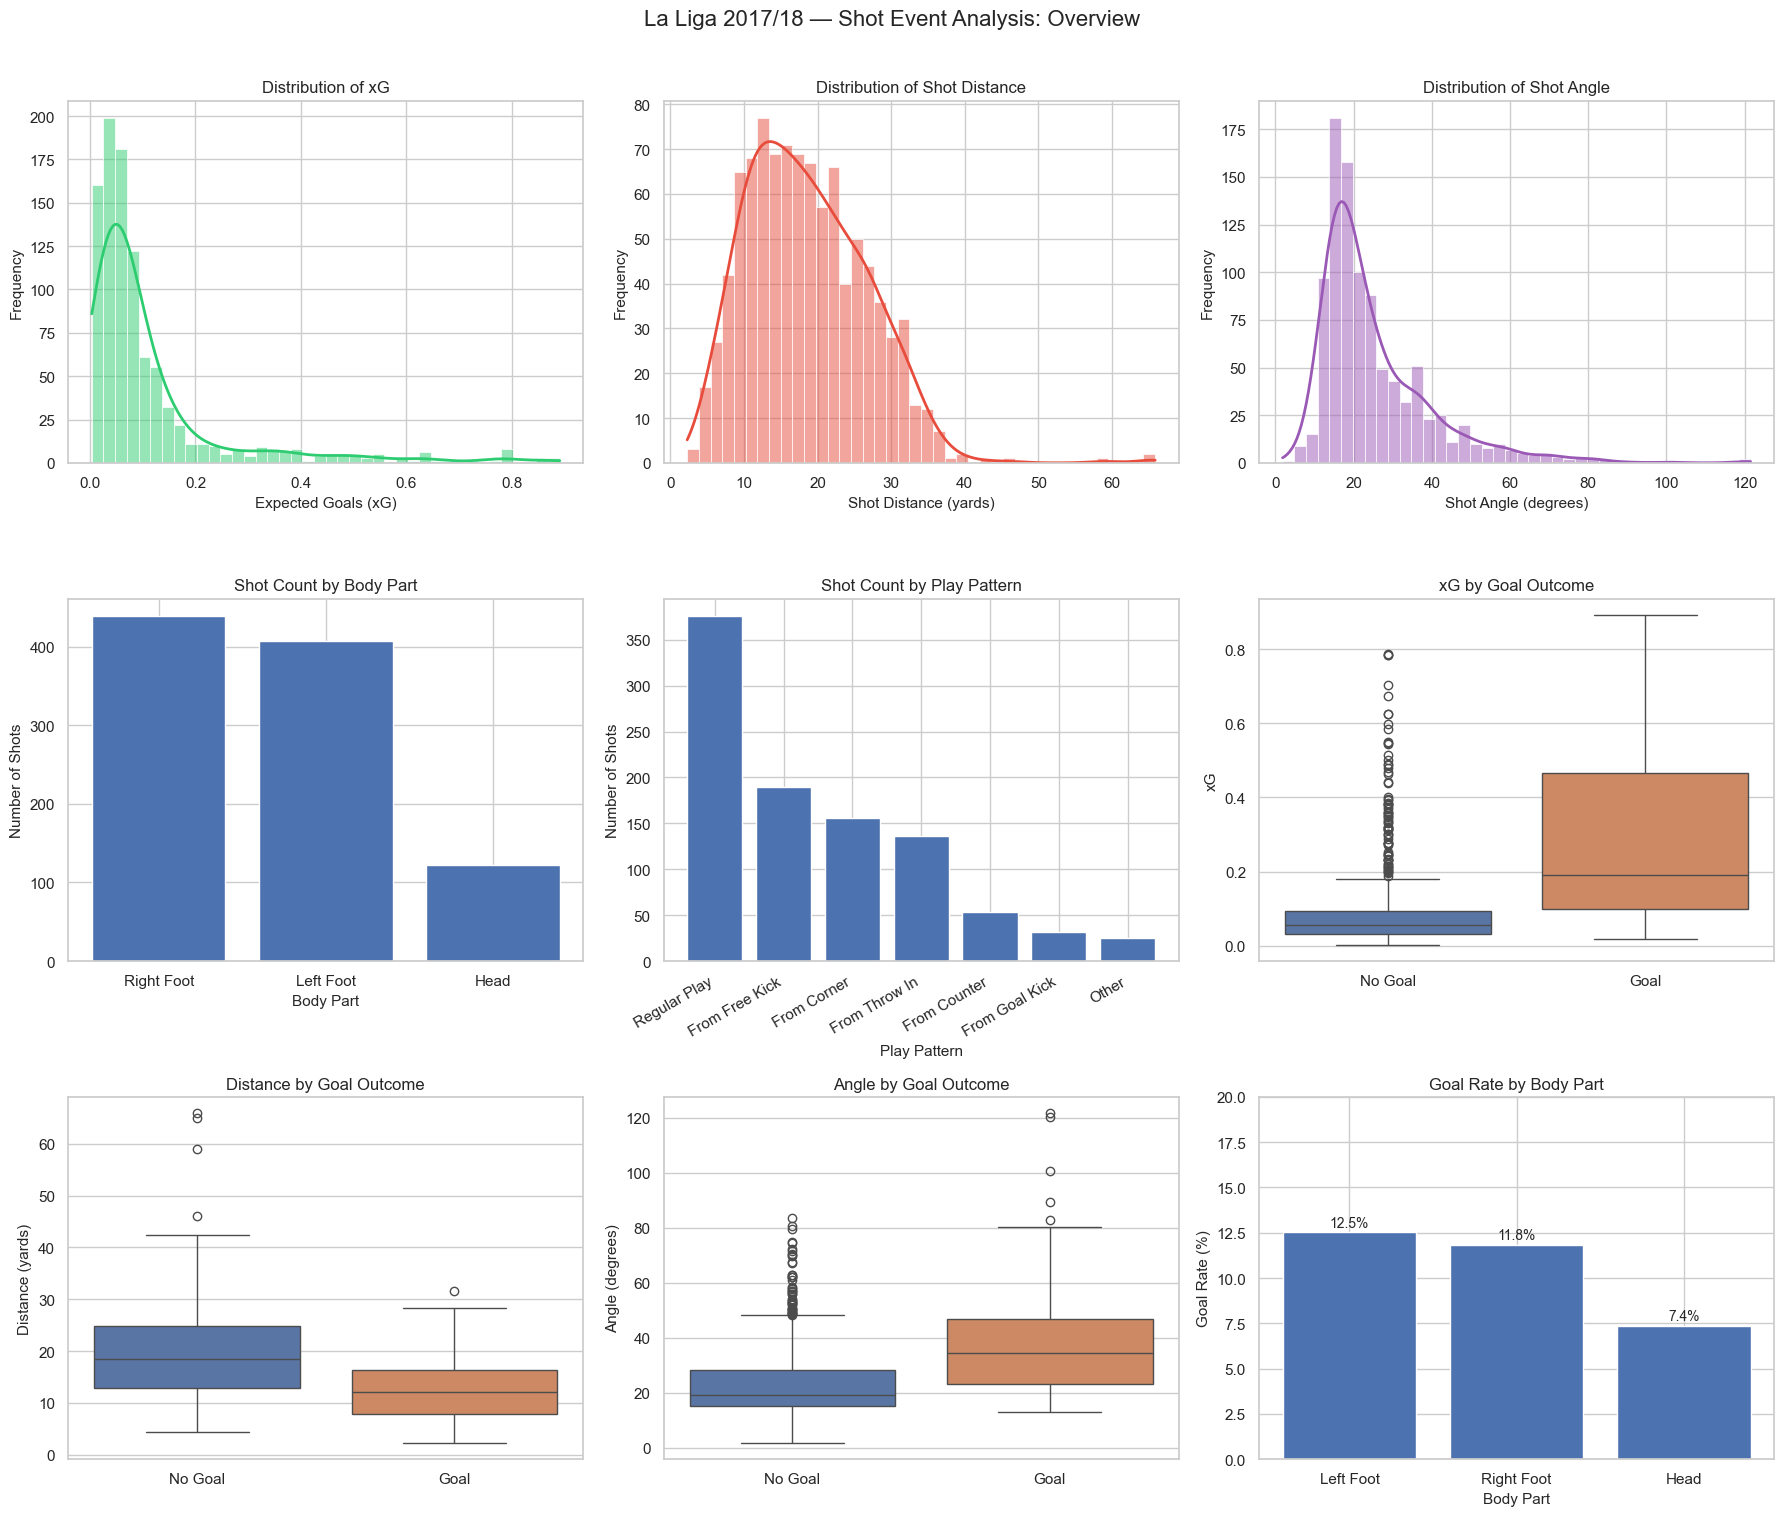

In [15]:
import os
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Distribution of xG
sns.histplot(df["xg"], bins=40, ax=axes[0,0], color="#2ecc71",edgecolor="white", linewidth=0.5, kde=True, line_kws={"color": "#1a8a4a", "linewidth": 2})
axes[0,0].set_xlabel("Expected Goals (xG)", fontsize=11)
axes[0,0].set_ylabel("Frequency", fontsize=11)
axes[0,0].set_title("Distribution of xG", fontsize=12)

# Distribution of shot distance
sns.histplot(df["distance"], bins=40, ax=axes[0,1], color="#e74c3c",edgecolor="white", linewidth=0.5, kde=True,line_kws={"color": "#a93226", "linewidth": 2})
axes[0,1].set_xlabel("Shot Distance (yards)", fontsize=11)
axes[0,1].set_ylabel("Frequency", fontsize=11)
axes[0,1].set_title("Distribution of Shot Distance", fontsize=12)

# Distribution of shot angle
sns.histplot(df["angle"], bins=40, ax=axes[0,2], color="#9b59b6",edgecolor="white", linewidth=0.5, kde=True, line_kws={"color": "#6c3483", "linewidth": 2})
axes[0,2].set_xlabel("Shot Angle (degrees)", fontsize=11)
axes[0,2].set_ylabel("Frequency", fontsize=11)
axes[0,2].set_title("Distribution of Shot Angle", fontsize=12)

# Shot count by body part
body_counts = df["body_part"].value_counts()
axes[1,0].bar(body_counts.index, body_counts.values, color="#4C72B0", edgecolor="white")
axes[1,0].set_xlabel("Body Part", fontsize=11)
axes[1,0].set_ylabel("Number of Shots", fontsize=11)
axes[1,0].set_title("Shot Count by Body Part", fontsize=12)

# Shot count by play pattern
pattern_counts = df["play_pattern"].value_counts()
axes[1,1].bar(pattern_counts.index, pattern_counts.values, color="#4C72B0", edgecolor="white")
axes[1,1].set_xlabel("Play Pattern", fontsize=11)
axes[1,1].set_ylabel("Number of Shots", fontsize=11)
axes[1,1].set_title("Shot Count by Play Pattern", fontsize=12)
axes[1,1].tick_params(axis="x", rotation=30)
for label in axes[1,1].get_xticklabels():
    label.set_ha("right")

# Box plots of xG, distance, angle by goal outcome
df["goal_label"] = df["goal"].map({0: "No Goal", 1: "Goal"})
sns.boxplot(data=df, x="goal_label", y="xg", ax=axes[1,2], hue="goal_label", palette={"No Goal": "#4C72B0", "Goal": "#DD8452"}, order=["No Goal", "Goal"], legend=False)
axes[1,2].set_xlabel("")
axes[1,2].set_ylabel("xG", fontsize=11)
axes[1,2].set_title("xG by Goal Outcome", fontsize=12)

# Box plot of distance by goal outcome
sns.boxplot(data=df, x="goal_label", y="distance", ax=axes[2,0], hue="goal_label", palette={"No Goal": "#4C72B0", "Goal": "#DD8452"}, order=["No Goal", "Goal"], legend=False)
axes[2,0].set_xlabel("")
axes[2,0].set_ylabel("Distance (yards)", fontsize=11)
axes[2,0].set_title("Distance by Goal Outcome", fontsize=12)

# Box plot of angle by goal outcome
sns.boxplot(data=df, x="goal_label", y="angle", ax=axes[2,1], hue="goal_label", palette={"No Goal": "#4C72B0", "Goal": "#DD8452"},order=["No Goal", "Goal"], legend=False)
axes[2,1].set_xlabel("")
axes[2,1].set_ylabel("Angle (degrees)", fontsize=11)
axes[2,1].set_title("Angle by Goal Outcome", fontsize=12)

# Goal rate by body part
goal_rate_bp = df.groupby("body_part")["goal"].mean().sort_values(ascending=False)
axes[2,2].bar(goal_rate_bp.index, goal_rate_bp.values * 100, color="#4C72B0", edgecolor="white")
axes[2,2].set_xlabel("Body Part", fontsize=11)
axes[2,2].set_ylabel("Goal Rate (%)", fontsize=11)
axes[2,2].set_title("Goal Rate by Body Part", fontsize=12)
axes[2,2].set_ylim(0, 20)
for i, v in enumerate(goal_rate_bp.values):
    axes[2,2].text(i, v * 100 + 0.3, f"{v*100:.1f}%", ha="center", fontsize=10)

# Finalize layout and save figure
df.drop(columns=["goal_label"], inplace=True)
plt.suptitle("La Liga 2017/18 — Shot Event Analysis: Overview", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig_overview_grid.png", dpi=150, bbox_inches="tight")
plt.show()


### Shot map

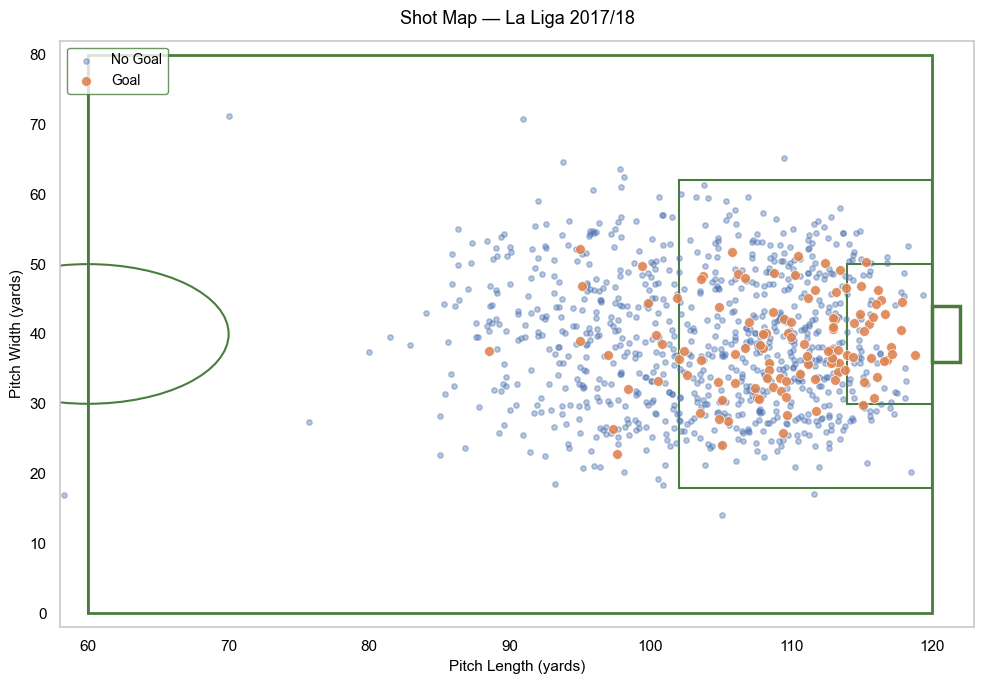

In [17]:
# ── Shot map on the attacking half of the pitch ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

# Draw the pitch background
ax.set_facecolor("white")
# Pitch outline (attacking half only: x from 60 to 120)
ax.add_patch(plt.Rectangle((60, 0), 60, 80,fill=False, edgecolor="#4a7c3f", linewidth=2))
# Halfway line
ax.plot([60, 60], [0, 80], color="#4a7c3f", linewidth=1.5)
# Penalty area
ax.add_patch(plt.Rectangle((102, 18), 18, 44,fill=False, edgecolor="#4a7c3f", linewidth=1.5))
# Six-yard box
ax.add_patch(plt.Rectangle((114, 30), 6, 20,fill=False, edgecolor="#4a7c3f", linewidth=1.5))
# Goal
ax.add_patch(plt.Rectangle((120, 36), 2, 8,fill=False, edgecolor="#4a7c3f", linewidth=2.5))
# Penalty spot
ax.plot(108, 40, "o", color="#4a7c3f", markersize=3)
# Centre circle arc (partial)
centre_circle = plt.Circle((60, 40), 10, fill=False,edgecolor="#4a7c3f", linewidth=1.5)
ax.add_patch(centre_circle)

# Re drive locations
with open("final_df.json", "r") as f:
    data = json.load(f)
df_raw = pd.DataFrame(data)
df_raw = df_raw[df_raw["shot.body_part.name"] != "Other"].reset_index(drop=True)
df["loc_x"] = df_raw["location"].apply(lambda v: v[0])
df["loc_y"] = df_raw["location"].apply(lambda v: v[1])

# Plot shots
no_goals = df[df["goal"] == 0]
goals    = df[df["goal"] == 1]

ax.scatter(no_goals["loc_x"], no_goals["loc_y"],c="#4C72B0", s=15, alpha=0.4, label="No Goal", zorder=3)
ax.scatter(goals["loc_x"], goals["loc_y"],c="#DD8452", s=50, alpha=0.9, label="Goal",edgecolors="white", linewidth=0.5, zorder=4)

# Labels and formatting
ax.set_xlim(58, 123)
ax.set_ylim(-2, 82)
ax.set_xlabel("Pitch Length (yards)", fontsize=11, color="black")
ax.set_ylabel("Pitch Width (yards)", fontsize=11, color="black")
ax.set_title("Shot Map — La Liga 2017/18", fontsize=13, color="black", pad=12)
ax.tick_params(colors="black")
ax.grid(False)
ax.legend(loc="upper left", fontsize=10, facecolor="white", labelcolor="black", framealpha=0.8, edgecolor="#4a7c3f")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("figures/fig_shot_map.png", dpi=150, bbox_inches="tight")
plt.show()


## Univariate analysis

### Shapiro-Wilk normality test

In [18]:
for var in ["xg", "distance", "angle"]:
    stat, p = stats.shapiro(df[var])
    print(f"{var:>10}: W = {stat:.4f}, p-value = {p:.4e}")

        xg: W = 0.6218, p-value = 1.2419e-41
  distance: W = 0.9596, p-value = 1.0568e-15
     angle: W = 0.8102, p-value = 3.1086e-32


### QQ plots for the quantitative variables

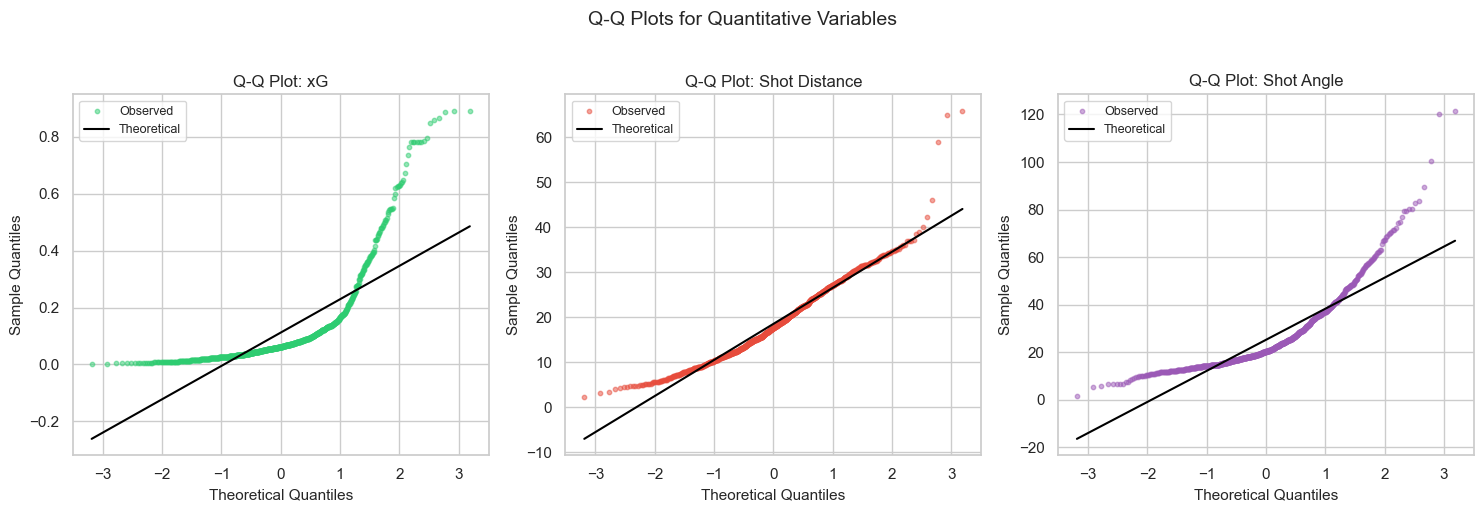

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var, title, color in zip(
    axes,
    ["xg", "distance", "angle"],
    ["xG", "Shot Distance", "Shot Angle"],
    ["#2ecc71", "#e74c3c", "#9b59b6"]
):
    (osm, osr), (slope, intercept, r) = stats.probplot(df[var], dist="norm")
    ax.scatter(osm, osr, color=color, alpha=0.5, s=10, label="Observed")
    ax.plot(osm, slope * np.array(osm) + intercept,
            color="black", linewidth=1.5, label="Theoretical")
    ax.set_xlabel("Theoretical Quantiles", fontsize=11)
    ax.set_ylabel("Sample Quantiles", fontsize=11)
    ax.set_title(f"Q-Q Plot: {title}", fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle("Q-Q Plots for Quantitative Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_qqplots.png", dpi=150, bbox_inches="tight")
plt.show()

### 95% Confidence intervals for mean xG, distance, angle

In [20]:
for var in ["xg", "distance", "angle"]:
    n    = len(df[var])
    mean = df[var].mean()
    se   = stats.sem(df[var])
    ci   = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"{var:>10}: mean = {mean:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")

        xg: mean = 0.1122, 95% CI = (0.1028, 0.1215)
  distance: mean = 18.5415, 95% CI = (18.0267, 19.0563)
     angle: mean = 25.2749, 95% CI = (24.3611, 26.1887)


### One sample t-test on mean xG: H0: mu = 0.10

In [21]:
t_stat, p_val = stats.ttest_1samp(df["xg"], popmean=0.10)
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value     = {p_val:.4e}")
print(f"mean xG     = {df['xg'].mean():.4f}")

t-statistic = 2.5556
p-value     = 1.0752e-02
mean xG     = 0.1122


### Sample size determination: foot shots vs headers

In [22]:
p1 = df[df["body_part"].isin(["Right Foot", "Left Foot"])]["goal"].mean()
p2 = df[df["body_part"] == "Head"]["goal"].mean()

effect_size = abs(p1 - p2) / np.sqrt((p1*(1-p1) + p2*(1-p2)) / 2)
analysis    = TTestIndPower()
n_required  = analysis.solve_power(effect_size=effect_size,
                                    alpha=0.05,
                                    power=0.80,
                                    alternative="two-sided")
print(f"Foot goal rate:   {p1:.4f}")
print(f"Header goal rate: {p2:.4f}")
print(f"Effect size:      {effect_size:.4f}")
print(f"Required n per group (alpha=0.05, power=0.80): {n_required:.1f}")

Foot goal rate:   0.1217
Header goal rate: 0.0738
Effect size:      0.1621
Required n per group (alpha=0.05, power=0.80): 598.5


### Box plots of xG, distance and angle

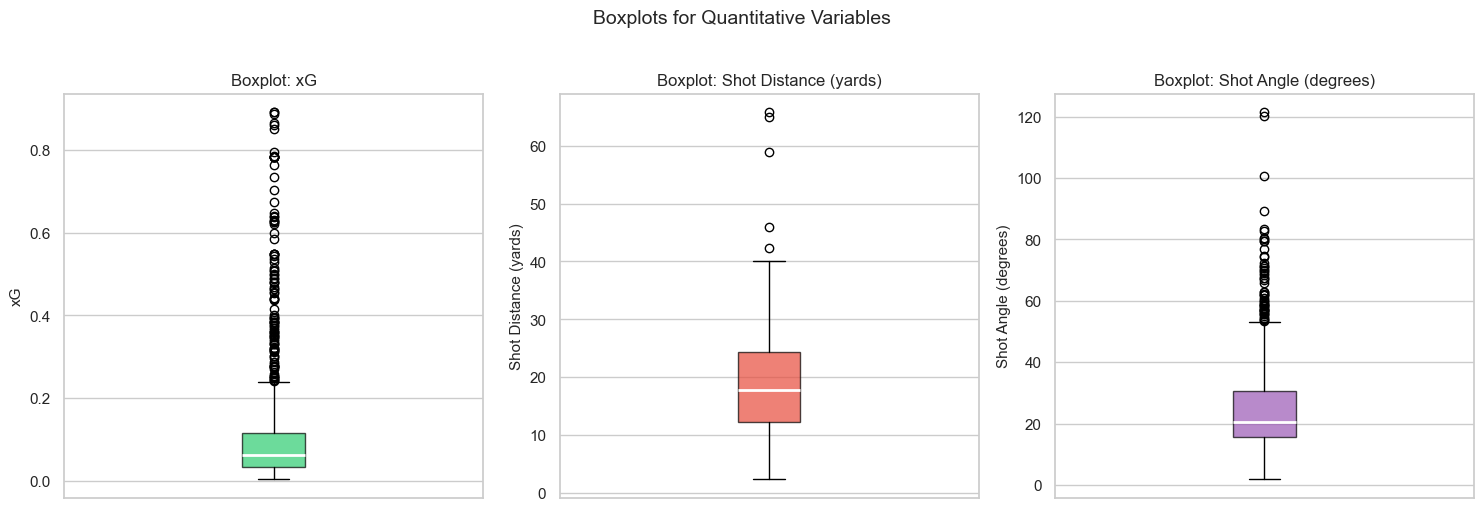

In [23]:
# ── Boxplots for the three quantitative variables ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var, title, color in zip(
    axes,
    ["xg", "distance", "angle"],
    ["xG", "Shot Distance (yards)", "Shot Angle (degrees)"],
    ["#2ecc71", "#e74c3c", "#9b59b6"]
):
    bp = ax.boxplot(df[var], patch_artist=True,
                    medianprops={"color": "white", "linewidth": 2})
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.7)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f"Boxplot: {title}", fontsize=12)
    ax.set_xticks([])

plt.suptitle("Boxplots for Quantitative Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_boxplots_univariate.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation analysis

### Pearson Matrix

              xg  distance   angle
xg        1.0000   -0.5337  0.6639
distance -0.5337    1.0000 -0.7370
angle     0.6639   -0.7370  1.0000


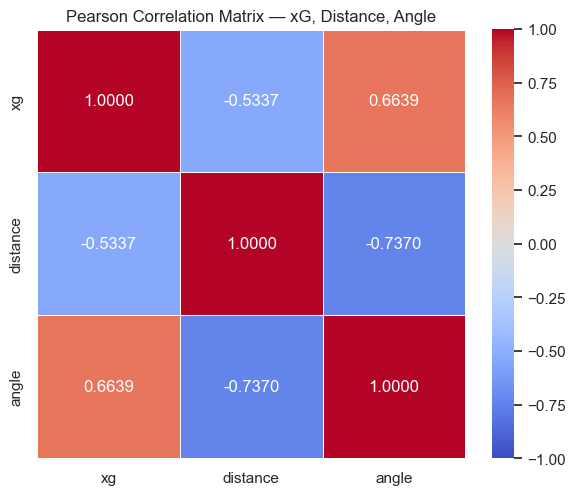

In [25]:
# Correlation matrix
corr_matrix = df[["xg", "distance", "angle"]].corr(method="pearson")
print(corr_matrix.round(4))

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={"size": 12}, ax=ax)
ax.set_title("Pearson Correlation Matrix — xG, Distance, Angle", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Categorical variable analysis


### Chi-square test: body part × goal

In [26]:
ct_bp = pd.crosstab(df["body_part"], df["goal"])
print("\nContingency table:")
print(ct_bp)
chi2, p, dof, expected = chi2_contingency(ct_bp)
print(f"\nchi2 = {chi2:.4f}, p-value = {p:.4e}, df = {dof}")


Contingency table:
goal          0   1
body_part          
Head        113   9
Left Foot   356  51
Right Foot  387  52

chi2 = 2.4959, p-value = 2.8709e-01, df = 2


### Chi-square test: play pattern × goal

In [27]:
ct_pp = pd.crosstab(df["play_pattern"], df["goal"])
print("\nContingency table:")
print(ct_pp)
chi2, p, dof, expected = chi2_contingency(ct_pp)
print(f"\nchi2 = {chi2:.4f}, p-value = {p:.4e}, df = {dof}")


Contingency table:
goal              0   1
play_pattern           
From Corner     145  11
From Counter     47   6
From Free Kick  175  15
From Goal Kick   28   4
From Throw In   118  18
Other            17   8
Regular Play    326  50

chi2 = 17.3161, p-value = 8.1890e-03, df = 6


### Chi-square test: under pressure × goal

In [28]:
ct_up = pd.crosstab(df["under_pressure"], df["goal"])
print("\nContingency table:")
print(ct_up)
chi2, p, dof, expected = chi2_contingency(ct_up)
print(f"\nchi2 = {chi2:.4f}, p-value = {p:.4e}, df = {dof}")


Contingency table:
goal              0   1
under_pressure         
False           727  93
True            129  19

chi2 = 0.1476, p-value = 7.0083e-01, df = 1


### Chi-square test: first time × goal

In [29]:
ct_ft = pd.crosstab(df["first_time"], df["goal"])
print("\nContingency table:")
print(ct_ft)
chi2, p, dof, expected = chi2_contingency(ct_ft)
print(f"\nchi2 = {chi2:.4f}, p-value = {p:.4e}, df = {dof}")


Contingency table:
goal          0   1
first_time         
False       589  56
True        267  56

chi2 = 14.9237, p-value = 1.1195e-04, df = 1


### Stacked bar chart: goal rate by categorical variables

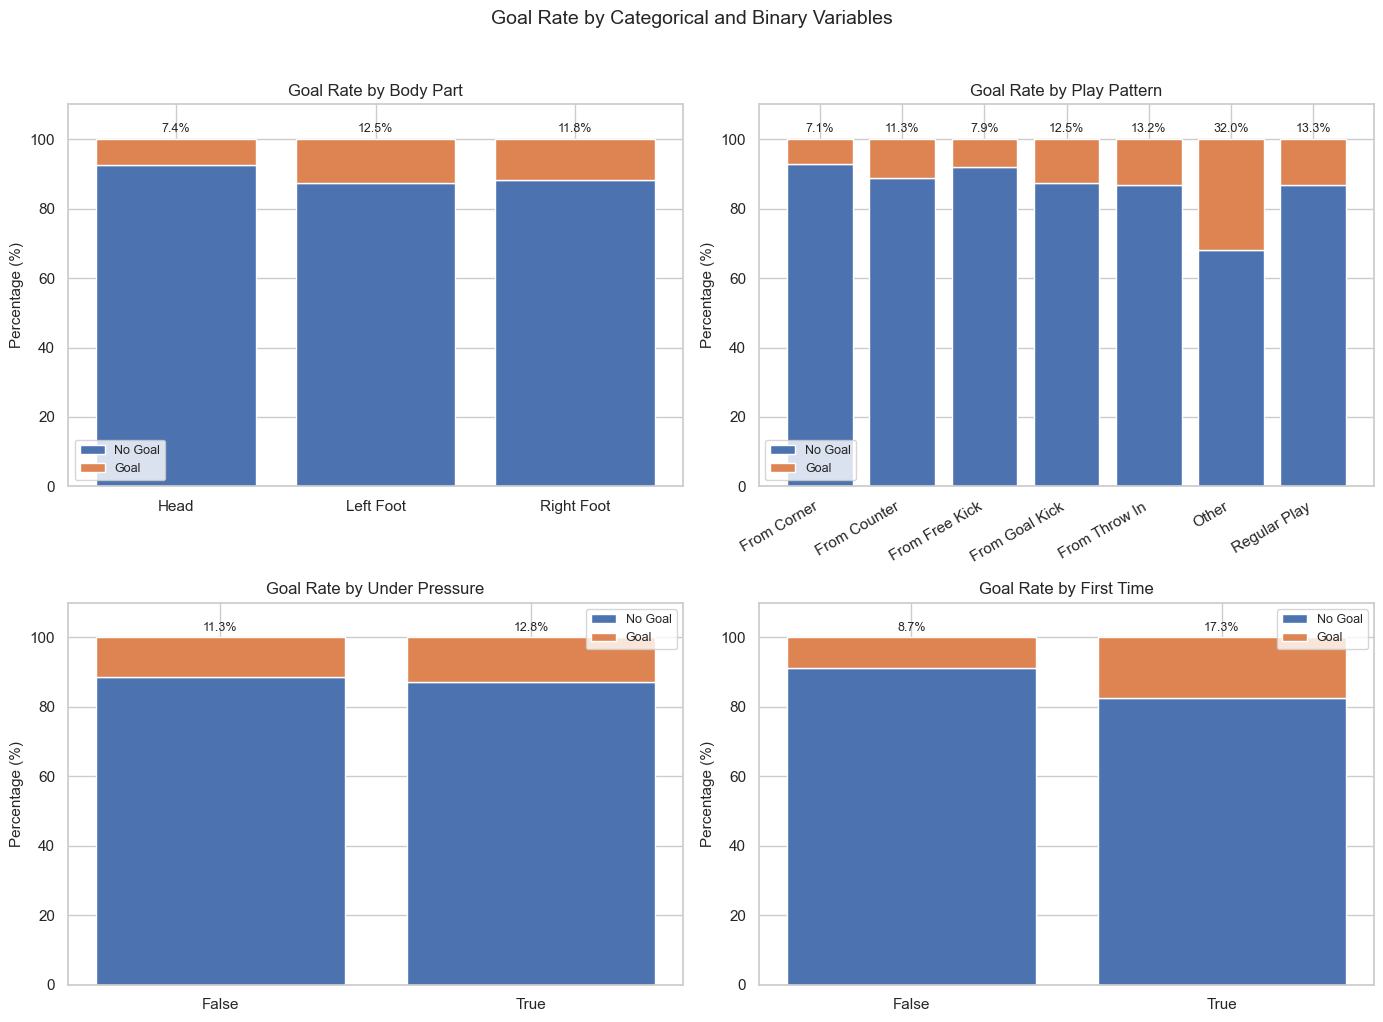

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var, title in zip(
    axes.flatten(),
    ["body_part", "play_pattern", "under_pressure", "first_time"],
    ["Body Part", "Play Pattern", "Under Pressure", "First Time"]
):
    goal_rates = df.groupby(var)["goal"].mean() * 100
    no_goal_rates = 100 - goal_rates
    categories = goal_rates.index

    ax.bar(categories, no_goal_rates, color="#4C72B0",
           edgecolor="white", label="No Goal")
    ax.bar(categories, goal_rates, bottom=no_goal_rates,
           color="#DD8452", edgecolor="white", label="Goal")
    ax.set_ylabel("Percentage (%)", fontsize=11)
    ax.set_title(f"Goal Rate by {title}", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 110)
    if var == "play_pattern":
        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_ha("right")
    for i, (cat, rate) in enumerate(goal_rates.items()):
        ax.text(i, 102, f"{rate:.1f}%", ha="center", fontsize=9)

for ax, var in zip(axes.flatten(),
                   ["body_part", "play_pattern",
                    "under_pressure", "first_time"]):
    if var in ["under_pressure", "first_time"]:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["False", "True"])

plt.suptitle("Goal Rate by Categorical and Binary Variables",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_categorical_goalrates.png", dpi=150,
            bbox_inches="tight")
plt.show()


## Analysis of variance (ANOVA)

###  xG by body part

In [32]:
groups_bp = [df[df["body_part"] == bp]["xg"].values
             for bp in df["body_part"].unique()]
f_stat, p_val = f_oneway(*groups_bp)
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_val:.4e}")

F-statistic = 2.2770
p-value     = 1.0314e-01


#### Post-hoc Tukey HSD test for xG by body part

In [33]:
tukey_bp = pairwise_tukeyhsd(df["xg"], df["body_part"], alpha=0.05)
print(tukey_bp)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2   meandiff p-adj   lower  upper  reject
----------------------------------------------------------
     Head  Left Foot   0.0166 0.5223 -0.0193 0.0525  False
     Head Right Foot   0.0303 0.1123 -0.0052 0.0659  False
Left Foot Right Foot   0.0137 0.3696 -0.0102 0.0376  False
----------------------------------------------------------


### xG by play pattern

In [34]:
groups_pp = [df[df["play_pattern"] == pp]["xg"].values
             for pp in df["play_pattern"].unique()]
f_stat, p_val = f_oneway(*groups_pp)
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_val:.4e}")

F-statistic = 10.1903
p-value     = 5.9636e-11


#### Post-hoc Tukey HSD test for xG by play pattern

In [35]:
tukey_pp = pairwise_tukeyhsd(df["xg"], df["play_pattern"], alpha=0.05)
print(tukey_pp)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   From Corner   From Counter   0.0718 0.0295  0.0041  0.1396   True
   From Corner From Free Kick  -0.0233 0.7486 -0.0693  0.0228  False
   From Corner From Goal Kick   0.0346 0.8797 -0.0481  0.1173  False
   From Corner  From Throw In   0.0046    1.0 -0.0454  0.0546  False
   From Corner          Other   0.1874    0.0  0.0956  0.2792   True
   From Corner   Regular Play   0.0218 0.6927 -0.0188  0.0623  False
  From Counter From Free Kick  -0.0951 0.0005 -0.1613 -0.0289   True
  From Counter From Goal Kick  -0.0372 0.9114 -0.1326  0.0582  False
  From Counter  From Throw In  -0.0673 0.0616 -0.1363  0.0017  False
  From Counter          Other   0.1156 0.0171  0.0122   0.219   True
  From Counter   Regular Play  -0.0501 0.2143 -0.1126  0.0125  False
From Free Kick From Goal Kick   0.

### Box plots of xG by body part and play pattern

/var/folders/bq/r76_1wc93pl6s86vc6hbz4zw0000gn/T/ipykernel_40486/3357596066.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(bp_groups, labels=["Head", "Left Foot", "Right Foot"],
/var/folders/bq/r76_1wc93pl6s86vc6hbz4zw0000gn/T/ipykernel_40486/3357596066.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(pp_groups, labels=pp_order, patch_artist=True)


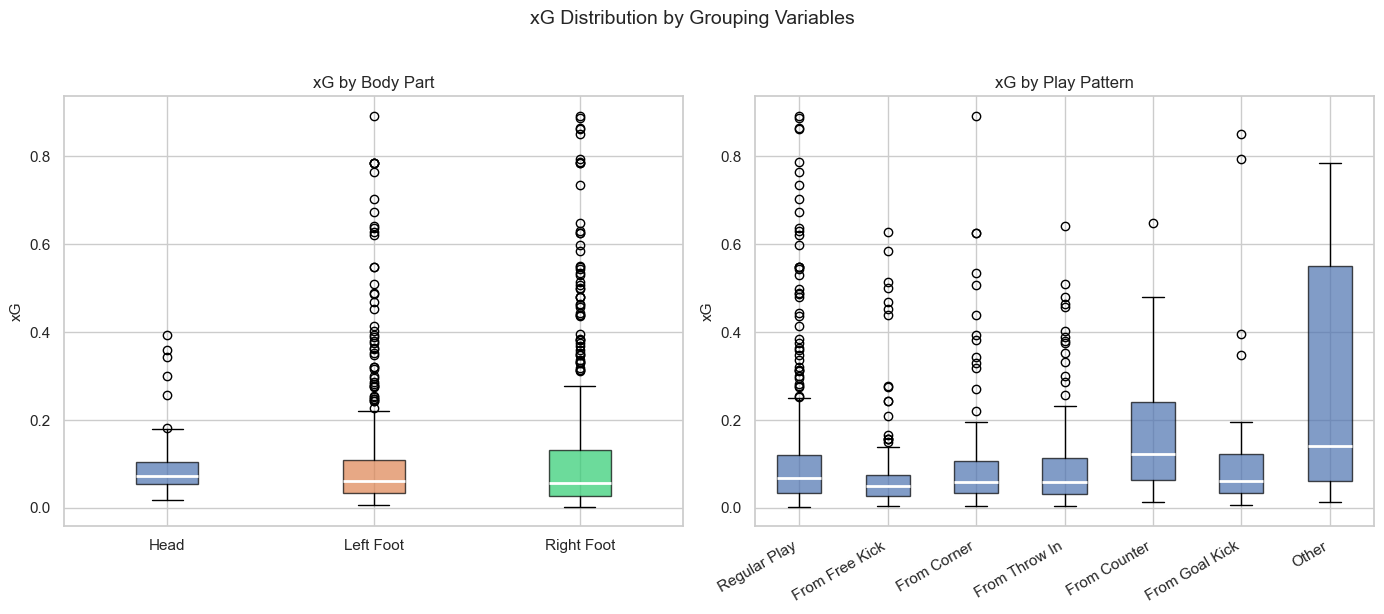

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# xG by body part
bp_groups = [df[df["body_part"] == bp]["xg"].values
             for bp in ["Head", "Left Foot", "Right Foot"]]
bp1 = axes[0].boxplot(bp_groups, labels=["Head", "Left Foot", "Right Foot"],
                       patch_artist=True)
colors_bp = ["#4C72B0", "#DD8452", "#2ecc71"]
for patch, color in zip(bp1["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp1["medians"]:
    median.set_color("white")
    median.set_linewidth(2)
axes[0].set_ylabel("xG", fontsize=11)
axes[0].set_title("xG by Body Part", fontsize=12)

# xG by play pattern
pp_order = ["Regular Play", "From Free Kick", "From Corner",
            "From Throw In", "From Counter", "From Goal Kick", "Other"]
pp_groups = [df[df["play_pattern"] == pp]["xg"].values for pp in pp_order]
bp2 = axes[1].boxplot(pp_groups, labels=pp_order, patch_artist=True)
for patch in bp2["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)
for median in bp2["medians"]:
    median.set_color("white")
    median.set_linewidth(2)
axes[1].set_ylabel("xG", fontsize=11)
axes[1].set_title("xG by Play Pattern", fontsize=12)
axes[1].tick_params(axis="x", rotation=30)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.suptitle("xG Distribution by Grouping Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_anova_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


## Logistic Regression

### Feature preprocessing

In [38]:
X = df[["distance", "angle", "under_pressure", "first_time"]].copy()
X["under_pressure"] = X["under_pressure"].astype(int)
X["first_time"] = X["first_time"].astype(int)
X_sm = sm.add_constant(X)
y = df["goal"]

### Fit logistic regression model

In [39]:
model  = sm.Logit(y, X_sm)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.309246
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   goal   No. Observations:                  968
Model:                          Logit   Df Residuals:                      963
Method:                           MLE   Df Model:                            4
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.1368
Time:                        17:47:50   Log-Likelihood:                -299.35
converged:                       True   LL-Null:                       -346.81
Covariance Type:            nonrobust   LLR p-value:                 1.186e-19
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.8702      0.707     -2.644      0.008      -3.257      -0.484
distance         

### Odds ratio and confidence intervals

In [40]:
odds_ratios = np.exp(result.params)
conf_int    = np.exp(result.conf_int())
odds_table  = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "CI Lower":   conf_int[0],
    "CI Upper":   conf_int[1],
    "p-value":    result.pvalues
}).round(4)
print(odds_table)

                Odds Ratio  CI Lower  CI Upper  p-value
const               0.1541    0.0385    0.6165   0.0082
distance            0.9303    0.8818    0.9815   0.0082
angle               1.0300    1.0101    1.0502   0.0029
under_pressure      0.7418    0.4083    1.3479   0.3270
first_time          1.4612    0.9309    2.2937   0.0992


### Find optimal threshold

In [41]:
y_pred_prob = result.predict(X_sm)

thresholds  = np.arange(0.05, 0.95, 0.01)
f1_scores   = [f1_score(y, (y_pred_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)
print(f"\nOptimal threshold: {best_threshold:.2f}")
print(f"Best F1 score:     {best_f1:.4f}")


Optimal threshold: 0.21
Best F1 score:     0.3898


### Predicted probabilities

In [42]:
y_pred      = (y_pred_prob >= best_threshold).astype(int)

print(classification_report(y, y_pred, target_names=["No Goal", "Goal"]))
print(f"AUC = {roc_auc_score(y, y_pred_prob):.4f}")

              precision    recall  f1-score   support

     No Goal       0.92      0.91      0.92       856
        Goal       0.37      0.41      0.39       112

    accuracy                           0.85       968
   macro avg       0.65      0.66      0.65       968
weighted avg       0.86      0.85      0.85       968

AUC = 0.7571


### Plots

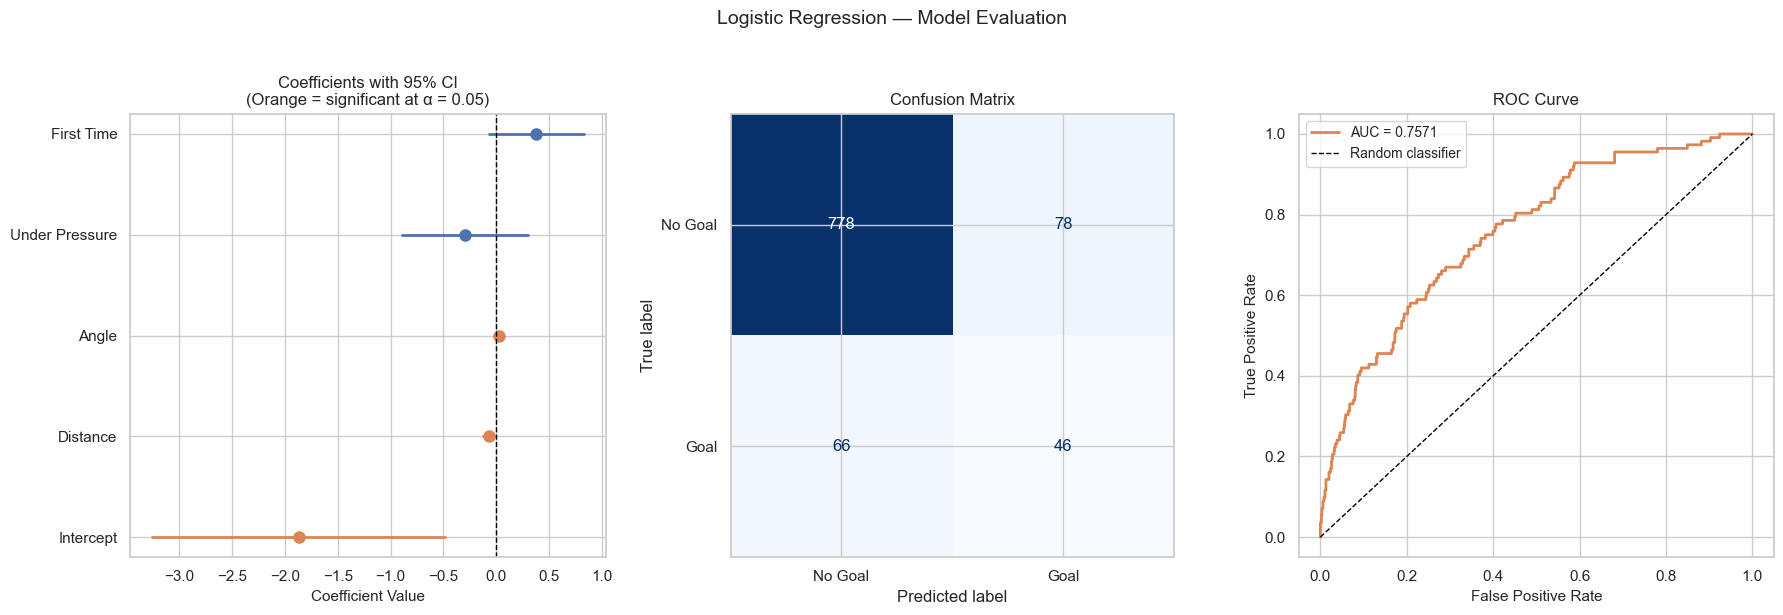

In [43]:
# Plots: coefficient plot, confusion matrix, ROC curve
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Coefficient plot
coef_names = ["Intercept", "Distance", "Angle",
              "Under Pressure", "First Time"]
coefs      = result.params.values
cis        = result.conf_int().values
colors     = ["#DD8452" if p < 0.05 else "#4C72B0"
              for p in result.pvalues]

for i, (name, coef, ci, color) in enumerate(
        zip(coef_names, coefs, cis, colors)):
    axes[0].plot([ci[0], ci[1]], [i, i], color=color, linewidth=2)
    axes[0].plot(coef, i, "o", color=color, markersize=8)

axes[0].axvline(x=0, color="black", linewidth=1, linestyle="--")
axes[0].set_yticks(range(len(coef_names)))
axes[0].set_yticklabels(coef_names, fontsize=11)
axes[0].set_xlabel("Coefficient Value", fontsize=11)
axes[0].set_title("Coefficients with 95% CI\n"
                  "(Orange = significant at \u03b1 = 0.05)", fontsize=12)

# Confusion matrix
cm   = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Goal", "Goal"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix", fontsize=12)

# ROC curve
fpr, tpr, _ = roc_curve(y, y_pred_prob)
auc_score   = roc_auc_score(y, y_pred_prob)

axes[2].plot(fpr, tpr, color="#DD8452", linewidth=2,
             label=f"AUC = {auc_score:.4f}")
axes[2].plot([0, 1], [0, 1], color="black", linewidth=1,
             linestyle="--", label="Random classifier")
axes[2].set_xlabel("False Positive Rate", fontsize=11)
axes[2].set_ylabel("True Positive Rate", fontsize=11)
axes[2].set_title("ROC Curve", fontsize=12)
axes[2].legend(fontsize=10)

plt.suptitle("Logistic Regression — Model Evaluation", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_logistic_evaluation.png", dpi=150,
            bbox_inches="tight")
plt.show()
